---
title: "Wikidata Item Profile"
format:
  html:
    toc: false
    code-fold: true
    code-summary: "Show code"
execute:
  echo: false
  warning: false
  error: false
jupyter: python3
---

# Wikidata Item Profile

This notebook-backed page queries Wikidata with SPARQL and renders a styled HTML profile.

To profile another item, change the `item_id` value in Cell 3 and re-render the site.

https://www.sprengel-museum.de/ausstellungen/aktuell/abenteuer-abstraktion 		



In [5]:
from IPython.display import HTML, Markdown
from wikidata_profile import (
    build_statement_query,
    fetch_sparql_bindings,
    properties_from_bindings,
    render_profile_html,
)

In [6]:
item_id = "Q138572982"
item_id = item_id.strip().upper()

if not item_id.startswith("Q") or not item_id[1:].isdigit():
    raise ValueError("item_id must be a Wikidata Q-id like Q42 or Q138547468")

query = build_statement_query(item_id)
Markdown(
    f"## SPARQL Query Used for {item_id}\n```sparql\n" + query + "\n```"
 )

## SPARQL Query Used for Q138572982
```sparql
SELECT ?property ?propertyLabel ?value ?valueLabel WHERE {
  BIND(wd:Q138572982 AS ?item)
  ?item ?p ?statement .
  ?property wikibase:claim ?p .
  ?statement ?ps ?value .
  ?property wikibase:statementProperty ?ps .

  SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }
}
ORDER BY ?propertyLabel
```

In [7]:
bindings = fetch_sparql_bindings(query)
properties = properties_from_bindings(bindings)
len(bindings)

17

In [8]:
HTML(render_profile_html(item_id, properties))

## Visualizing the Wikidata Item as a Graph
The following cell renders a graph visualization of the relationships for the selected Wikidata item. This helps to see how the item is connected to other entities via its properties.

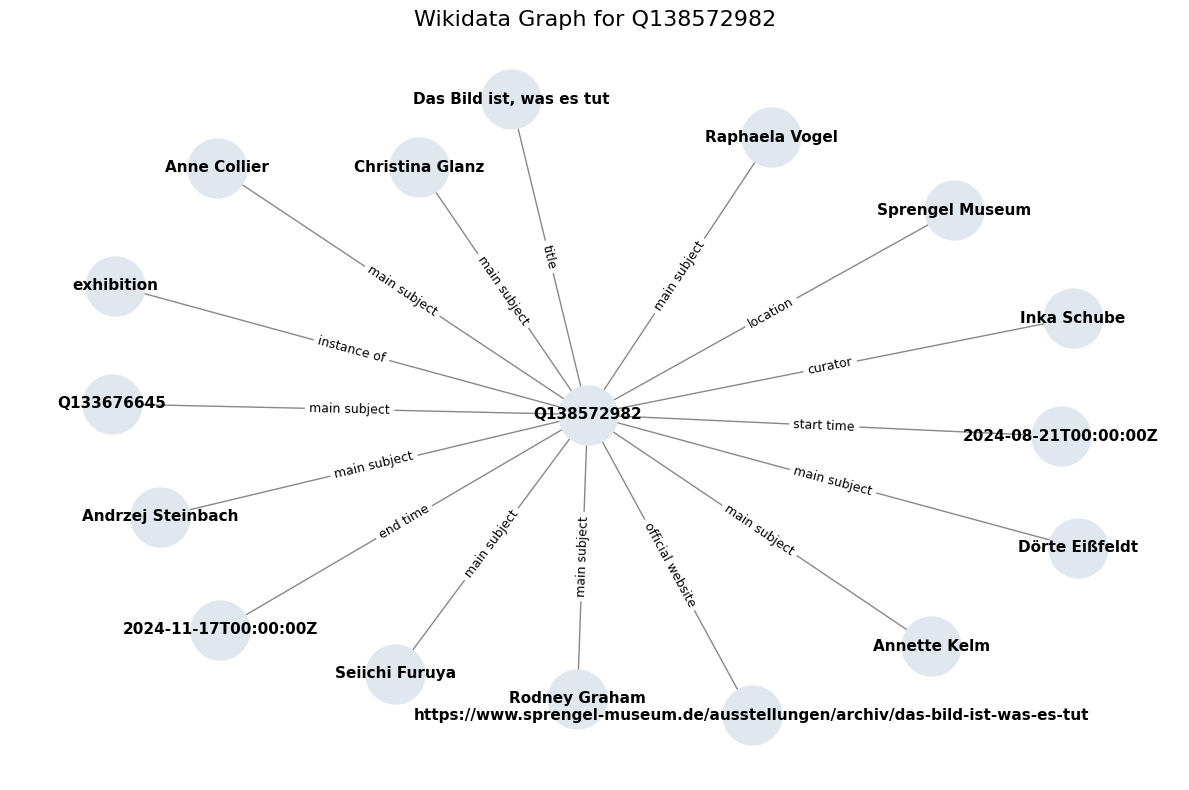

In [9]:
# Visualize the Wikidata item as a graph
# Requires: networkx, matplotlib
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

# Build a directed graph from the bindings
G = nx.DiGraph()

for b in bindings:
    subj = b.get('itemLabel', {}).get('value', item_id)
    prop = b.get('propertyLabel', {}).get('value', b.get('property', {}).get('value', ''))
    obj = b.get('valueLabel', {}).get('value', b.get('value', {}).get('value', ''))
    if obj and prop:
        G.add_edge(subj, obj, label=prop)

if G.number_of_edges() == 0:
    print('No graph data available for this item.')
else:
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.7, seed=42)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_nodes(G, pos, node_color='#e0e7ef', node_size=1800)
    nx.draw_networkx_edges(G, pos, edge_color='#888', arrows=True, arrowstyle='-|>', arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, label_pos=0.5)
    plt.title(f"Wikidata Graph for {item_id}", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()